In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# For regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
# Load the data
data = pd.read_csv('synthetic_child_mental_health_dataset.csv')

In [4]:
data.head()

,Age,Gender,Absence_Days,Substance_Misuse,Parent_MH_Issue,Looked_After_Child,School_Exclusion,Disability,Mental_Health_Problem
0,14,Boy,24,0,1,0,0,0,1
1,16,Boy,25,0,0,0,0,0,0
2,13,Girl,35,0,0,0,0,1,0
3,17,Girl,16,0,0,0,0,1,0
4,17,Boy,12,1,1,0,0,0,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1787 entries, 0 to 1786
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    1787 non-null   int64 
 1   Gender                 1787 non-null   object
 2   Absence_Days           1787 non-null   int64 
 3   Substance_Misuse       1787 non-null   int64 
 4   Parent_MH_Issue        1787 non-null   int64 
 5   Looked_After_Child     1787 non-null   int64 
 6   School_Exclusion       1787 non-null   int64 
 7   Disability             1787 non-null   int64 
 8   Mental_Health_Problem  1787 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 125.8+ KB


In [6]:
data.describe()

,Age,Absence_Days,Substance_Misuse,Parent_MH_Issue,Looked_After_Child,School_Exclusion,Disability,Mental_Health_Problem
count,1787.000000,1787.000000,1787.000000,1787.000000,1787.000000,1787.000000,1787.000000,1787.000000
mean,13.492445,24.960828,0.087857,0.151651,0.074426,0.039172,0.122552,0.172916
std,2.304707,14.288643,0.283166,0.358782,0.262537,0.194058,0.328014,0.378280
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.500000,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,17.000000,49.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
data.isnull().sum()

Age                      0
Gender                   0
Absence_Days             0
Substance_Misuse         0
Parent_MH_Issue          0
Looked_After_Child       0
School_Exclusion         0
Disability               0
Mental_Health_Problem    0
dtype: int64

In [8]:
data.shape

(1787, 9)

In [9]:
# Check target variable distribution
print(f"\nTarget Variable (Mental_Health_Problem) Distribution:")
print(data['Mental_Health_Problem'].value_counts())
print(f"\nPercentage:")
print(data['Mental_Health_Problem'].value_counts(normalize=True) * 100)


Target Variable (Mental_Health_Problem) Distribution:
Mental_Health_Problem
0    1478
1     309
Name: count, dtype: int64

Percentage:
Mental_Health_Problem
0    82.70845
1    17.29155
Name: proportion, dtype: float64


## Data Preprocessing

In [10]:
# Encode categorical variables
le_gender = LabelEncoder()
data['Gender_Encoded'] = le_gender.fit_transform(data['Gender'])

In [11]:
feature_columns = ['Age', 'Gender_Encoded', 'Absence_Days', 'Substance_Misuse', 
                   'Parent_MH_Issue', 'Looked_After_Child', 'School_Exclusion', 'Disability']
target_column = 'Mental_Health_Problem'

In [12]:
X = data[feature_columns]
y = data[target_column]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
X_train.shape, X_test.shape

((1429, 8), (358, 8))

In [15]:
y_train.value_counts(normalize=True)

Mental_Health_Problem
0    0.827152
1    0.172848
Name: proportion, dtype: float64

In [16]:
y_test.value_counts(normalize=True)

Mental_Health_Problem
0    0.826816
1    0.173184
Name: proportion, dtype: float64

In [17]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Convert back to DataFrame for easier interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

In [19]:
# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_pred_proba_test = model.predict_proba(X_test)[:, 1]
        auc_test = roc_auc_score(y_test, y_pred_proba_test)
        y_pred_proba_train = model.predict_proba(X_train)[:, 1]
        auc_train = roc_auc_score(y_train, y_pred_proba_train)
    else:
        auc_train = None
        auc_test = None
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    if auc_test:
        print(f"Train AUC: {auc_train:.4f}")
        print(f"Test AUC: {auc_test:.4f}")
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred_test))
    
    # Return metrics for comparison
    return {
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test AUC': auc_test if auc_test else None,
        'Model Object': model
    }

In [20]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True),
    'Gradient Boost': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

In [21]:
#evaluate all models
results = []
for name, model in models.items():
    result = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    results.append(result)


Logistic Regression Results
Training Accuracy: 0.8572
Test Accuracy: 0.8743
Cross-validation Accuracy: 0.8488 (+/- 0.0306)
Train AUC: 0.8271
Test AUC: 0.8239

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       296
           1       0.74      0.42      0.54        62

    accuracy                           0.87       358
   macro avg       0.82      0.69      0.73       358
weighted avg       0.86      0.87      0.86       358


Decision Tree Results
Training Accuracy: 0.9671
Test Accuracy: 0.8156
Cross-validation Accuracy: 0.7978 (+/- 0.0427)
Train AUC: 0.9958
Test AUC: 0.6228

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       296
           1       0.45      0.29      0.35        62

    accuracy                           0.82       358
   macro avg       0.66      0.61      0.62       358
weighted avg       

In [22]:
# Create comparison dataframe
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model Object'} for r in results])
print("MODEL COMPARISON SUMMARY")
print(comparison_df.to_string(index=False))

MODEL COMPARISON SUMMARY
              Model  Train Accuracy  Test Accuracy  CV Mean   CV Std  Test AUC
Logistic Regression        0.857243       0.874302 0.848838 0.015299  0.823861
      Decision Tree        0.967110       0.815642 0.797762 0.021355  0.622820
      Random Forest        0.967110       0.832402 0.832062 0.011545  0.743488
                SVM        0.874038       0.860335 0.850249 0.008019  0.740056
     Gradient Boost        0.898530       0.843575 0.844657 0.010831  0.808767
            XGBoost        0.951015       0.832402 0.827160 0.016108  0.774956


## Visualize model comparisons

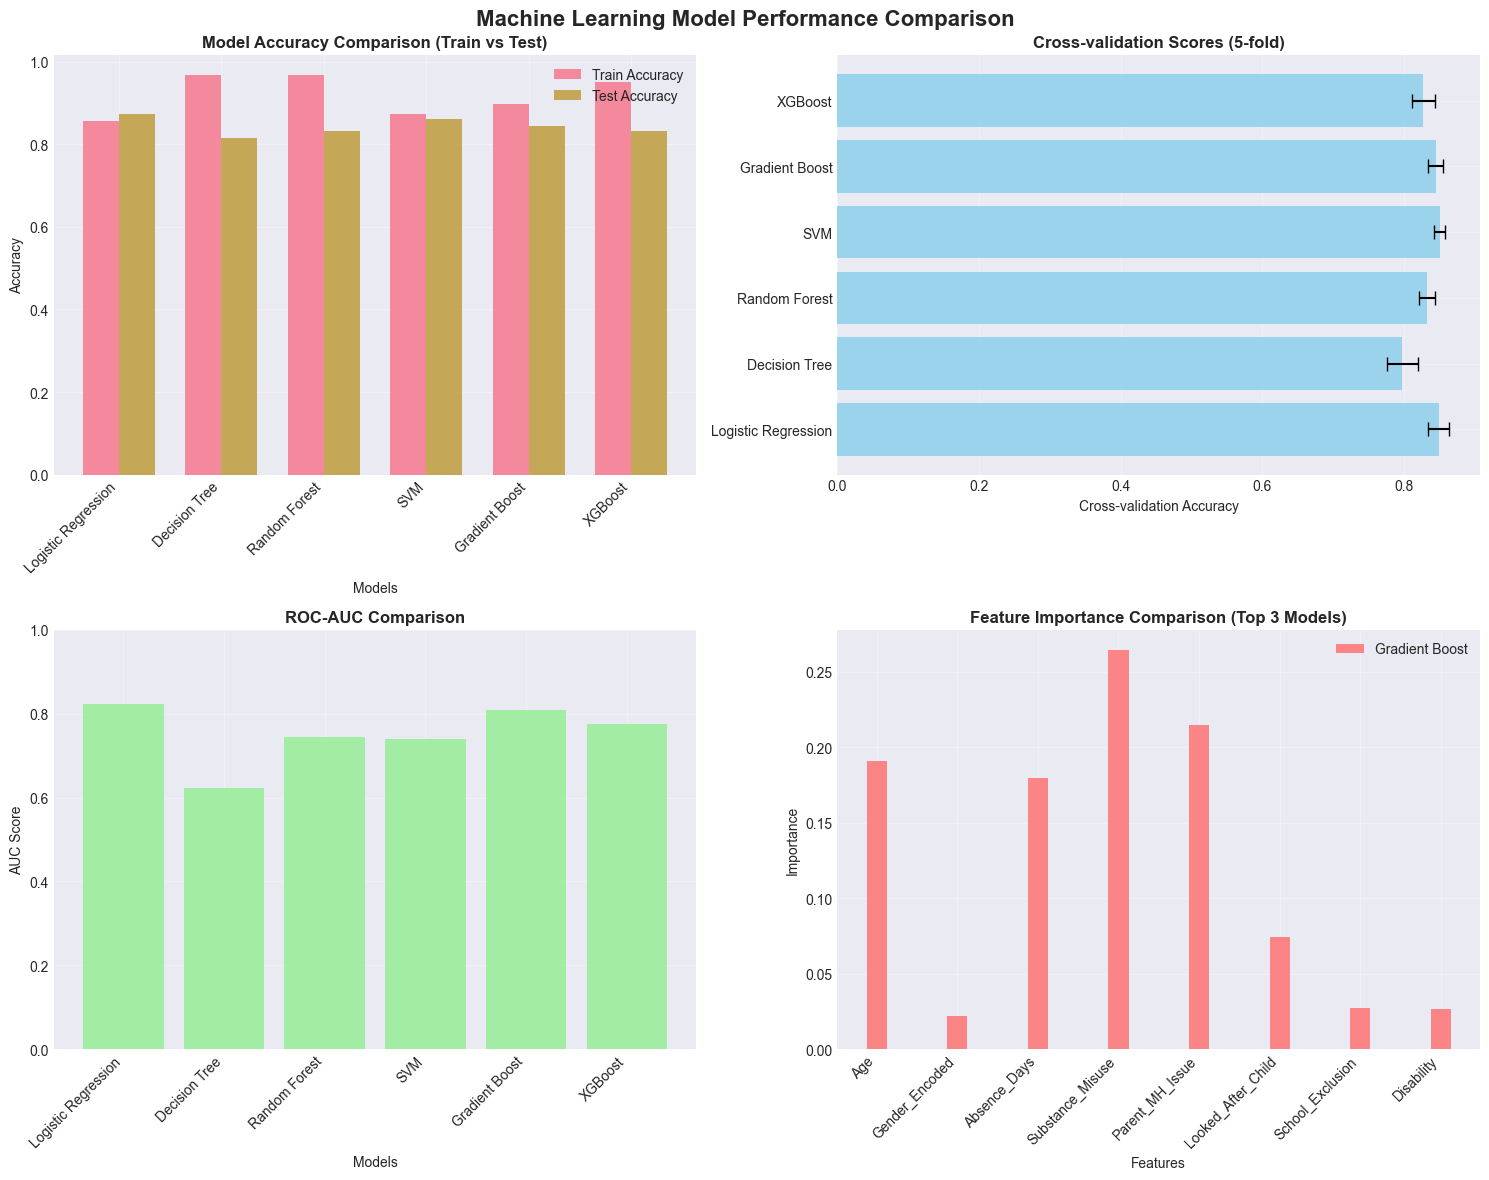

In [23]:
# Visualize model comparisons
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Model Accuracy Comparison
ax1 = axes[0, 0]
x = np.arange(len(comparison_df['Model']))
width = 0.35
ax1.bar(x - width/2, comparison_df['Train Accuracy'], width, label='Train Accuracy', alpha=0.8)
ax1.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison (Train vs Test)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cross-validation Scores
ax2 = axes[0, 1]
ax2.barh(comparison_df['Model'], comparison_df['CV Mean'], xerr=comparison_df['CV Std'], 
         capsize=5, alpha=0.8, color='skyblue')
ax2.set_xlabel('Cross-validation Accuracy')
ax2.set_title('Cross-validation Scores (5-fold)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: AUC Comparison (for models that support it)
ax3 = axes[1, 0]
auc_models = comparison_df[comparison_df['Test AUC'].notna()]
if len(auc_models) > 0:
    ax3.bar(auc_models['Model'], auc_models['Test AUC'], alpha=0.8, color='lightgreen')
    ax3.set_xlabel('Models')
    ax3.set_ylabel('AUC Score')
    ax3.set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
    ax3.set_xticklabels(auc_models['Model'], rotation=45, ha='right')
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'AUC not available for all models', 
             ha='center', va='center', transform=ax3.transAxes)

# Plot 4: Feature Importance Comparison (instead of multiple confusion matrices)
ax4 = axes[1, 1]
top_models = comparison_df.nlargest(3, 'Test Accuracy')['Model'].values

# Get feature importances from top 3 models
importance_data = {}
for model_name in top_models:
    model = next(r['Model Object'] for r in results if r['Model'] == model_name)
    if hasattr(model, 'feature_importances_'):
        importance_data[model_name] = model.feature_importances_

if importance_data:
    # Plot feature importance comparison
    x_pos = np.arange(len(feature_columns))
    width = 0.25
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for idx, (model_name, importance) in enumerate(importance_data.items()):
        offset = (idx - len(importance_data)/2) * width + width/2
        ax4.bar(x_pos + offset, importance, width, label=model_name, alpha=0.8, color=colors[idx % len(colors)])
    
    ax4.set_xlabel('Features')
    ax4.set_ylabel('Importance')
    ax4.set_title('Feature Importance Comparison (Top 3 Models)', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(feature_columns, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Feature importance not available for all models', 
             ha='center', va='center', transform=ax4.transAxes)

plt.suptitle('Machine Learning Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

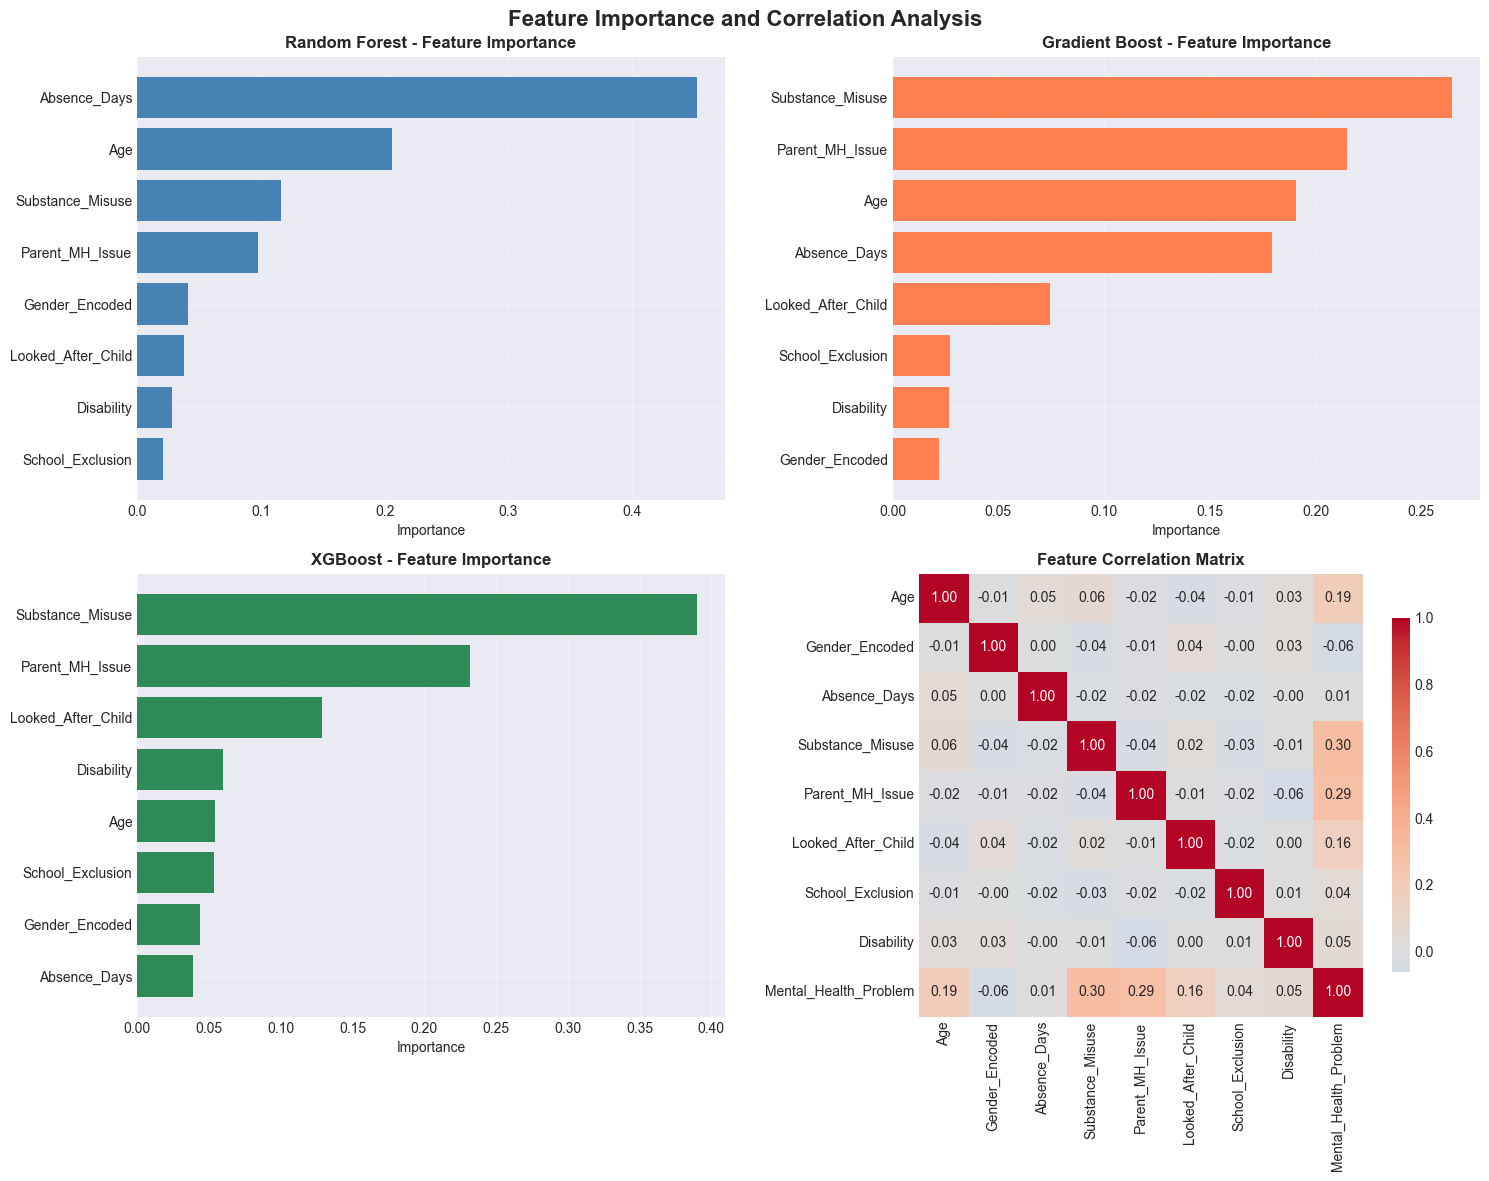

In [24]:
# Feature Importance Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Random Forest Feature Importance
rf_model = next(r['Model Object'] for r in results if r['Model'] == 'Random Forest')
rf_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

ax1 = axes[0, 0]
ax1.barh(rf_importance['feature'], rf_importance['importance'], color='steelblue')
ax1.set_xlabel('Importance')
ax1.set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3)

# Plot 2: Gradient Boost Feature Importance
gb_model = next(r['Model Object'] for r in results if r['Model'] == 'Gradient Boost')
gb_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

ax2 = axes[0, 1]
ax2.barh(gb_importance['feature'], gb_importance['importance'], color='coral')
ax2.set_xlabel('Importance')
ax2.set_title('Gradient Boost - Feature Importance', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)

# Plot 3: XGBoost Feature Importance
xgb_model = next(r['Model Object'] for r in results if r['Model'] == 'XGBoost')
xgb_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

ax3 = axes[1, 0]
ax3.barh(xgb_importance['feature'], xgb_importance['importance'], color='seagreen')
ax3.set_xlabel('Importance')
ax3.set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3)

# Plot 4: Correlation Matrix
ax4 = axes[1, 1]
correlation_matrix = data[feature_columns + [target_column]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax4, square=True, cbar_kws={"shrink": 0.8})
ax4.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Feature Importance and Correlation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_and_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## Hyperparameter tuning

In [25]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.8, 0.9, 1.0]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    }
}

In [26]:
param_grids

{'Random Forest': {'n_estimators': [100, 200, 300],
  'max_depth': [10, 20, 30, None],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4],
  'max_features': ['sqrt', 'log2']},
 'Gradient Boost': {'n_estimators': [100, 200, 300],
  'learning_rate': [0.01, 0.05, 0.1, 0.2],
  'max_depth': [3, 5, 7, 9],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4],
  'subsample': [0.8, 0.9, 1.0]},
 'XGBoost': {'n_estimators': [100, 200, 300],
  'learning_rate': [0.01, 0.05, 0.1, 0.2],
  'max_depth': [3, 5, 7, 9],
  'subsample': [0.8, 0.9, 1.0],
  'colsample_bytree': [0.8, 0.9, 1.0],
  'gamma': [0, 0.1, 0.2]}}

In [27]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
# Perform hyperparameter tuning for top 3 models
tuned_results = {}

for model_name in ['Random Forest', 'Gradient Boost', 'XGBoost']:
    print(f"Tuning {model_name}")
    
    # Get base model
    if model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42)
    elif model_name == 'Gradient Boost':
        base_model = GradientBoostingClassifier(random_state=42)
    else:  # XGBoost
        base_model = XGBClassifier(random_state=42, eval_metric='logloss')
    
    # Perform Grid Search with cross-validation
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[model_name],
        cv=10,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the grid search
    grid_search.fit(X_train_scaled, y_train)
    
    # Get best model
    best_model = grid_search.best_estimator_
    
    # Evaluate best model
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)
    y_pred_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    auc_score = roc_auc_score(y_test, y_pred_proba_test)
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test AUC: {auc_score:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_test))
    
    # Store results
    tuned_results[model_name] = {
        'best_model': best_model,
        'best_params': grid_search.best_params_,
        'cv_score': grid_search.best_score_,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'auc': auc_score
    }

Tuning Random Forest
Fitting 10 folds for each of 216 candidates, totalling 2160 fits

Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-validation Score: 0.8593
Training Accuracy: 0.9055
Test Accuracy: 0.8659
Test AUC: 0.7753

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       296
           1       0.68      0.44      0.53        62

    accuracy                           0.87       358
   macro avg       0.78      0.70      0.73       358
weighted avg       0.85      0.87      0.85       358

Tuning Gradient Boost
Fitting 10 folds for each of 1296 candidates, totalling 12960 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.9}
Best Cross-validation Score: 0.8544
Training Accuracy: 0.9013
Test Accuracy: 0.8492
Test AUC: 0.8113

In [28]:
# Compare Before and After Tuning
print("Performance comperison: before vs after")


comparison_data = []
for model_name in ['Random Forest', 'Gradient Boost', 'XGBoost']:
    # Get before tuning results
    before = next(r for r in results if r['Model'] == model_name)
    # Get after tuning results
    after = tuned_results[model_name]
    
    comparison_data.append({
        'Model': model_name,
        'Before Train Acc': before['Train Accuracy'],
        'After Train Acc': after['train_acc'],
        'Before Test Acc': before['Test Accuracy'],
        'After Test Acc': after['test_acc'],
        'Before CV Mean': before['CV Mean'],
        'After CV Mean': after['cv_score'],
        'Before AUC': before['Test AUC'],
        'After AUC': after['auc']
    })

comparison_df_tuned = pd.DataFrame(comparison_data)
print(comparison_df_tuned.to_string(index=False))

Performance comperison: before vs after
         Model  Before Train Acc  After Train Acc  Before Test Acc  After Test Acc  Before CV Mean  After CV Mean  Before AUC  After AUC
 Random Forest          0.967110         0.905528         0.832402        0.865922        0.832062       0.859332    0.743488   0.775256
Gradient Boost          0.898530         0.901330         0.843575        0.849162        0.844657       0.854437    0.808767   0.811301
       XGBoost          0.951015         0.888034         0.832402        0.854749        0.827160       0.855850    0.774956   0.804245


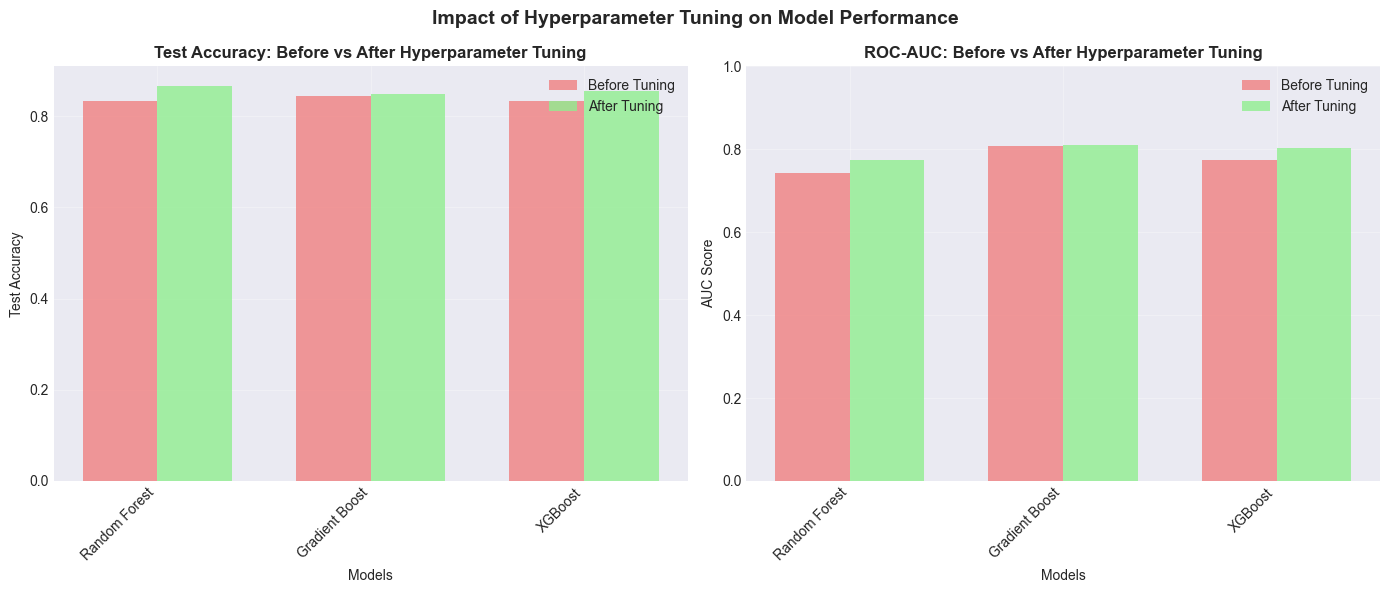

In [29]:
# Visualization of tuning results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Test Accuracy Comparison
ax1 = axes[0]
x = np.arange(len(comparison_df_tuned['Model']))
width = 0.35
ax1.bar(x - width/2, comparison_df_tuned['Before Test Acc'], width, label='Before Tuning', alpha=0.8, color='lightcoral')
ax1.bar(x + width/2, comparison_df_tuned['After Test Acc'], width, label='After Tuning', alpha=0.8, color='lightgreen')
ax1.set_xlabel('Models')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Test Accuracy: Before vs After Hyperparameter Tuning', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df_tuned['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: AUC Comparison
ax2 = axes[1]
ax2.bar(x - width/2, comparison_df_tuned['Before AUC'], width, label='Before Tuning', alpha=0.8, color='lightcoral')
ax2.bar(x + width/2, comparison_df_tuned['After AUC'], width, label='After Tuning', alpha=0.8, color='lightgreen')
ax2.set_xlabel('Models')
ax2.set_ylabel('AUC Score')
ax2.set_title('ROC-AUC: Before vs After Hyperparameter Tuning', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df_tuned['Model'], rotation=45, ha='right')
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Impact of Hyperparameter Tuning on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Final Model Evaluation with Best Tuned Model
print("Final model evaluation - best performing tuned model")

# Find the best model based on test accuracy
best_model_name = max(tuned_results.items(), key=lambda x: x[1]['test_acc'])[0]
best_model_data = tuned_results[best_model_name]
best_model = best_model_data['best_model']

print(f"\nBest Model: {best_model_name}")
print(f"Best Parameters: {best_model_data['best_params']}")
print(f"\nFinal Performance Metrics:")
print(f"Training Accuracy: {best_model_data['train_acc']:.4f}")
print(f"Test Accuracy: {best_model_data['test_acc']:.4f}")
print(f"Cross-validation Score: {best_model_data['cv_score']:.4f}")
print(f"AUC Score: {best_model_data['auc']:.4f}")

Final model evaluation - best performing tuned model

Best Model: Random Forest
Best Parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

Final Performance Metrics:
Training Accuracy: 0.9055
Test Accuracy: 0.8659
Cross-validation Score: 0.8593
AUC Score: 0.7753


In [31]:
# Final predictions
y_pred_final = best_model.predict(X_test_scaled)
y_pred_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)


In [32]:
print("cm final: ",cm_final)

cm final:  [[283  13]
 [ 35  27]]


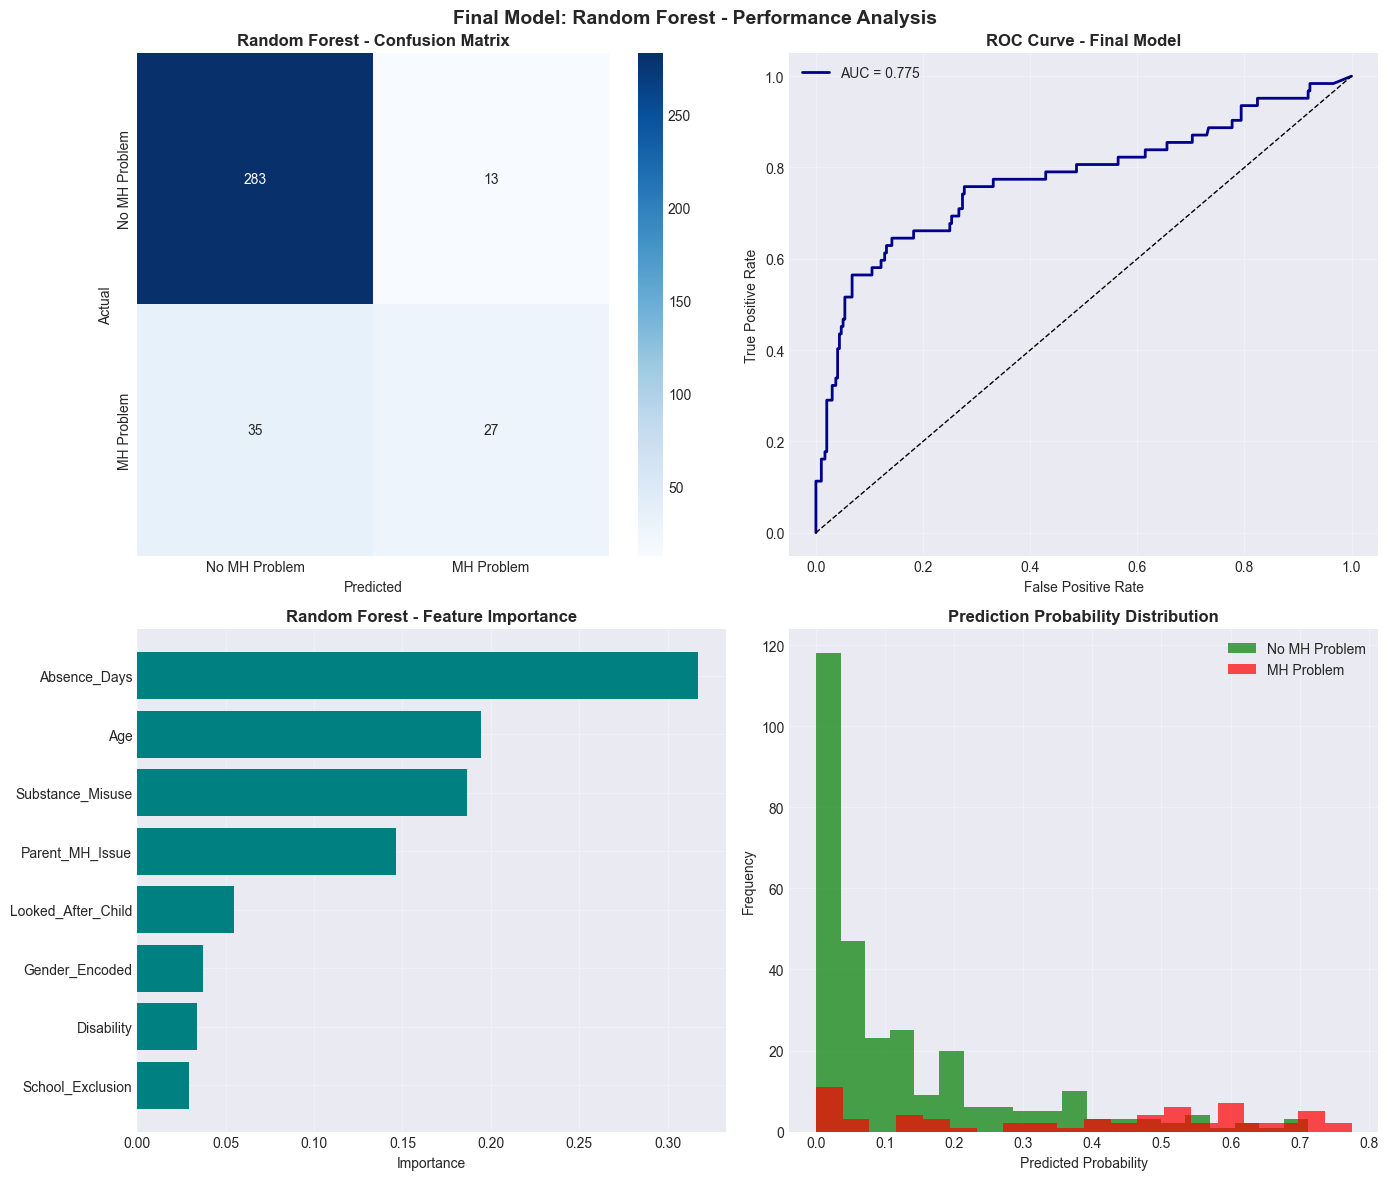

In [33]:
# Visualization of final model results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['No MH Problem', 'MH Problem'],
            yticklabels=['No MH Problem', 'MH Problem'])
ax1.set_title(f'{best_model_name} - Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
ax2.plot(fpr, tpr, linewidth=2, color='darkblue', label=f'AUC = {best_model_data["auc"]:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve - Final Model', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
# Feature Importance (if available)
ax3 = axes[1, 0]
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True)
    
    ax3.barh(importance_df['feature'], importance_df['importance'], color='teal')
    ax3.set_xlabel('Importance')
    ax3.set_title(f'{best_model_name} - Feature Importance', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)

# Prediction Distribution
ax4 = axes[1, 1]
ax4.hist(y_pred_proba_final[y_test==0], bins=20, alpha=0.7, label='No MH Problem', color='green')
ax4.hist(y_pred_proba_final[y_test==1], bins=20, alpha=0.7, label='MH Problem', color='red')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Final Model: {best_model_name} - Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# Print feature importance for the best model
if hasattr(best_model, 'feature_importances_'):
    print(f"\n{best_model_name} - Feature Importance Rankings:")
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    for idx, row in importance_df.iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")


Random Forest - Feature Importance Rankings:
  Absence_Days: 0.3174
  Age: 0.1943
  Substance_Misuse: 0.1867
  Parent_MH_Issue: 0.1464
  Looked_After_Child: 0.0548
  Gender_Encoded: 0.0371
  Disability: 0.0339
  School_Exclusion: 0.0295


In [35]:
feature_columns = ['Age', 'Substance_Misuse', 'Parent_MH_Issue', 'Looked_After_Child']
target_column = 'Mental_Health_Problem'

In [36]:
X = data[feature_columns]
y = data[target_column]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
X_train.shape, X_test.shape

((1429, 4), (358, 4))

In [39]:
y_train.value_counts(normalize=True)

Mental_Health_Problem
0    0.827152
1    0.172848
Name: proportion, dtype: float64

In [40]:
y_test.value_counts(normalize=True)

Mental_Health_Problem
0    0.826816
1    0.173184
Name: proportion, dtype: float64

In [41]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Convert back to DataFrame for easier interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

In [43]:
# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate probabilities for AUC
    if hasattr(model, "predict_proba"):
        y_pred_proba_test = model.predict_proba(X_test)[:, 1]
        auc_test = roc_auc_score(y_test, y_pred_proba_test)
        y_pred_proba_train = model.predict_proba(X_train)[:, 1]
        auc_train = roc_auc_score(y_train, y_pred_proba_train)
    else:
        auc_train = None
        auc_test = None
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    if auc_test:
        print(f"Train AUC: {auc_train:.4f}")
        print(f"Test AUC: {auc_test:.4f}")
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred_test))
    
    # Return metrics for comparison
    return {
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test AUC': auc_test if auc_test else None,
        'Model Object': model
    }

In [44]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True),
    'Gradient Boost': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

In [45]:
#evaluate all models
results = []
for name, model in models.items():
    result = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    results.append(result)


Logistic Regression Results
Training Accuracy: 0.8523
Test Accuracy: 0.8547
Cross-validation Accuracy: 0.8495 (+/- 0.0412)
Train AUC: 0.8163
Test AUC: 0.8160

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       296
           1       0.63      0.39      0.48        62

    accuracy                           0.85       358
   macro avg       0.76      0.67      0.70       358
weighted avg       0.84      0.85      0.84       358


Decision Tree Results
Training Accuracy: 0.8663
Test Accuracy: 0.8408
Cross-validation Accuracy: 0.8495 (+/- 0.0322)
Train AUC: 0.8285
Test AUC: 0.7652

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       296
           1       0.57      0.34      0.42        62

    accuracy                           0.84       358
   macro avg       0.72      0.64      0.67       358
weighted avg       

In [46]:
# Create comparison dataframe
comparison_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model Object'} for r in results])
print("MODEL COMPARISON SUMMARY")
print(comparison_df.to_string(index=False))

MODEL COMPARISON SUMMARY
              Model  Train Accuracy  Test Accuracy  CV Mean   CV Std  Test AUC
Logistic Regression        0.852344       0.854749 0.849550 0.020593  0.816042
      Decision Tree        0.866340       0.840782 0.849547 0.016078  0.765175
      Random Forest        0.866340       0.840782 0.852344 0.018420  0.802583
                SVM        0.860742       0.854749 0.846753 0.016987  0.776646
     Gradient Boost        0.866340       0.849162 0.855154 0.019409  0.823561
            XGBoost        0.866340       0.849162 0.853049 0.017791  0.809503


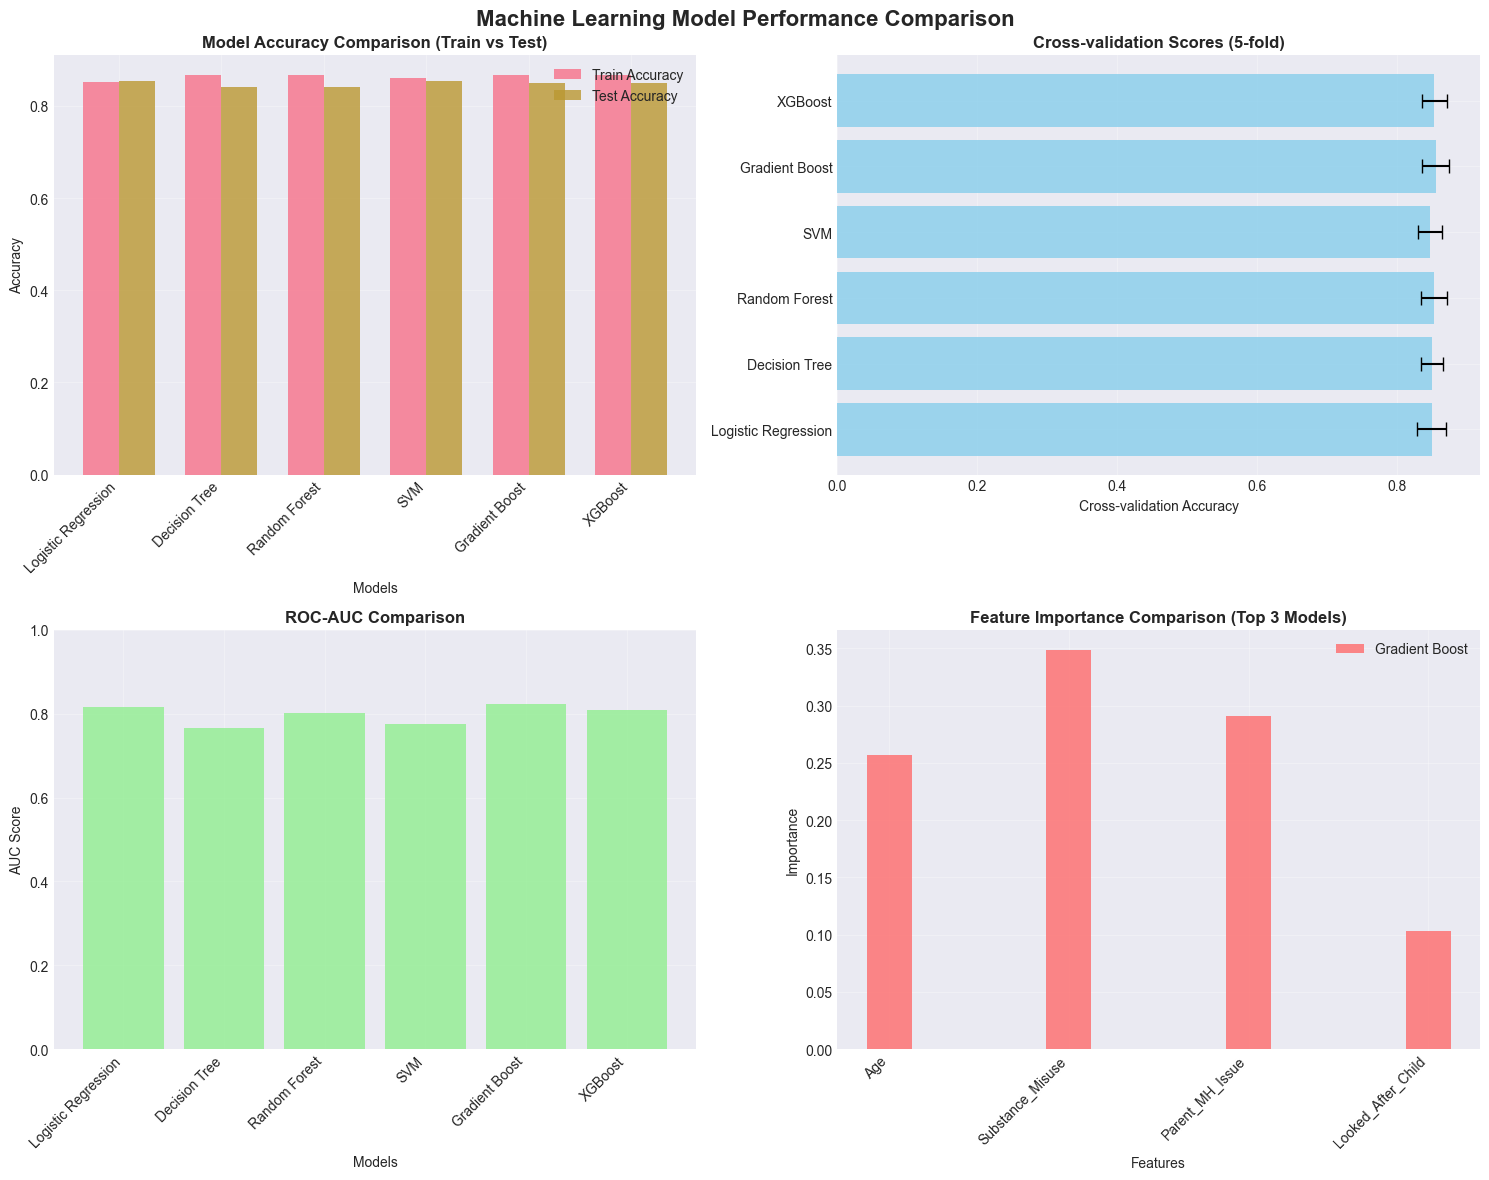

In [47]:
# Visualize model comparisons
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Model Accuracy Comparison
ax1 = axes[0, 0]
x = np.arange(len(comparison_df['Model']))
width = 0.35
ax1.bar(x - width/2, comparison_df['Train Accuracy'], width, label='Train Accuracy', alpha=0.8)
ax1.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8)
ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison (Train vs Test)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cross-validation Scores
ax2 = axes[0, 1]
ax2.barh(comparison_df['Model'], comparison_df['CV Mean'], xerr=comparison_df['CV Std'], 
         capsize=5, alpha=0.8, color='skyblue')
ax2.set_xlabel('Cross-validation Accuracy')
ax2.set_title('Cross-validation Scores (5-fold)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: AUC Comparison (for models that support it)
ax3 = axes[1, 0]
auc_models = comparison_df[comparison_df['Test AUC'].notna()]
if len(auc_models) > 0:
    ax3.bar(auc_models['Model'], auc_models['Test AUC'], alpha=0.8, color='lightgreen')
    ax3.set_xlabel('Models')
    ax3.set_ylabel('AUC Score')
    ax3.set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
    ax3.set_xticklabels(auc_models['Model'], rotation=45, ha='right')
    ax3.set_ylim([0, 1])
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'AUC not available for all models', 
             ha='center', va='center', transform=ax3.transAxes)

# Plot 4: Feature Importance Comparison (instead of multiple confusion matrices)
ax4 = axes[1, 1]
top_models = comparison_df.nlargest(3, 'Test Accuracy')['Model'].values

# Get feature importances from top 3 models
importance_data = {}
for model_name in top_models:
    model = next(r['Model Object'] for r in results if r['Model'] == model_name)
    if hasattr(model, 'feature_importances_'):
        importance_data[model_name] = model.feature_importances_

if importance_data:
    # Plot feature importance comparison
    x_pos = np.arange(len(feature_columns))
    width = 0.25
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for idx, (model_name, importance) in enumerate(importance_data.items()):
        offset = (idx - len(importance_data)/2) * width + width/2
        ax4.bar(x_pos + offset, importance, width, label=model_name, alpha=0.8, color=colors[idx % len(colors)])
    
    ax4.set_xlabel('Features')
    ax4.set_ylabel('Importance')
    ax4.set_title('Feature Importance Comparison (Top 3 Models)', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(feature_columns, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Feature importance not available for all models', 
             ha='center', va='center', transform=ax4.transAxes)

plt.suptitle('Machine Learning Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

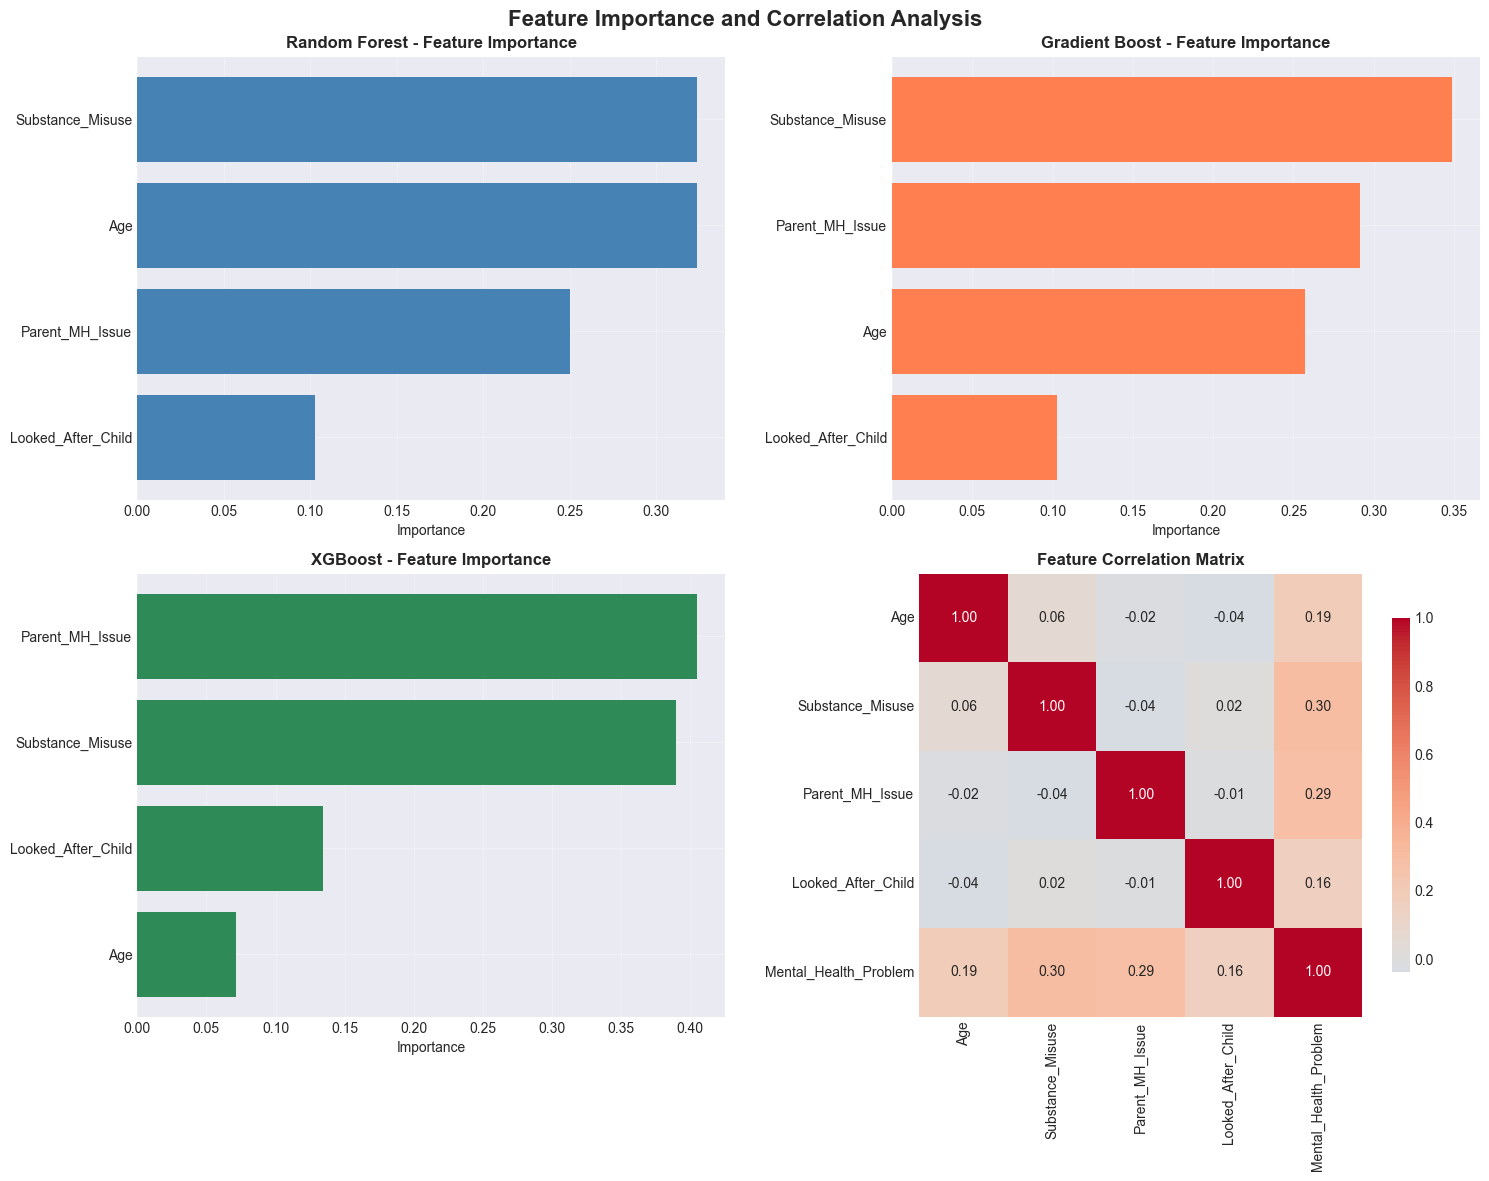

In [48]:
# Feature Importance Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Random Forest Feature Importance
rf_model = next(r['Model Object'] for r in results if r['Model'] == 'Random Forest')
rf_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

ax1 = axes[0, 0]
ax1.barh(rf_importance['feature'], rf_importance['importance'], color='steelblue')
ax1.set_xlabel('Importance')
ax1.set_title('Random Forest - Feature Importance', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3)

# Plot 2: Gradient Boost Feature Importance
gb_model = next(r['Model Object'] for r in results if r['Model'] == 'Gradient Boost')
gb_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

ax2 = axes[0, 1]
ax2.barh(gb_importance['feature'], gb_importance['importance'], color='coral')
ax2.set_xlabel('Importance')
ax2.set_title('Gradient Boost - Feature Importance', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)

# Plot 3: XGBoost Feature Importance
xgb_model = next(r['Model Object'] for r in results if r['Model'] == 'XGBoost')
xgb_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

ax3 = axes[1, 0]
ax3.barh(xgb_importance['feature'], xgb_importance['importance'], color='seagreen')
ax3.set_xlabel('Importance')
ax3.set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3)

# Plot 4: Correlation Matrix
ax4 = axes[1, 1]
correlation_matrix = data[feature_columns + [target_column]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax4, square=True, cbar_kws={"shrink": 0.8})
ax4.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.suptitle('Feature Importance and Correlation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_and_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.8, 0.9, 1.0]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    }
}

In [50]:
param_grids

{'Random Forest': {'n_estimators': [100, 200, 300],
  'max_depth': [10, 20, 30, None],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4],
  'max_features': ['sqrt', 'log2']},
 'Gradient Boost': {'n_estimators': [100, 200, 300],
  'learning_rate': [0.01, 0.05, 0.1, 0.2],
  'max_depth': [3, 5, 7, 9],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4],
  'subsample': [0.8, 0.9, 1.0]},
 'XGBoost': {'n_estimators': [100, 200, 300],
  'learning_rate': [0.01, 0.05, 0.1, 0.2],
  'max_depth': [3, 5, 7, 9],
  'subsample': [0.8, 0.9, 1.0],
  'colsample_bytree': [0.8, 0.9, 1.0],
  'gamma': [0, 0.1, 0.2]}}

In [51]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
# Perform hyperparameter tuning for top 3 models
tuned_results = {}

for model_name in ['Random Forest', 'Gradient Boost', 'XGBoost']:
    print(f"Tuning {model_name}")
    
    # Get base model
    if model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42)
    elif model_name == 'Gradient Boost':
        base_model = GradientBoostingClassifier(random_state=42)
    else:  # XGBoost
        base_model = XGBClassifier(random_state=42, eval_metric='logloss')
    
    # Perform Grid Search with cross-validation
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[model_name],
        cv=10,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit the grid search
    grid_search.fit(X_train_scaled, y_train)
    
    # Get best model
    best_model = grid_search.best_estimator_
    
    # Evaluate best model
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)
    y_pred_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    auc_score = roc_auc_score(y_test, y_pred_proba_test)
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test AUC: {auc_score:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_test))
    
    # Store results
    tuned_results[model_name] = {
        'best_model': best_model,
        'best_params': grid_search.best_params_,
        'cv_score': grid_search.best_score_,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'auc': auc_score
    }

Tuning Random Forest
Fitting 10 folds for each of 216 candidates, totalling 2160 fits

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-validation Score: 0.8579
Training Accuracy: 0.8663
Test Accuracy: 0.8408
Test AUC: 0.8026

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       296
           1       0.56      0.35      0.44        62

    accuracy                           0.84       358
   macro avg       0.72      0.65      0.67       358
weighted avg       0.82      0.84      0.83       358

Tuning Gradient Boost
Fitting 10 folds for each of 1296 candidates, totalling 12960 fits

Best Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300, 'subsample': 0.9}
Best Cross-validation Score: 0.8614
Training Accuracy: 0.8663
Test Accuracy: 0.8464
Test AUC: 0.7965


In [52]:
# Compare Before and After Tuning
print("Performance comperison: before vs after")


comparison_data = []
for model_name in ['Random Forest', 'Gradient Boost', 'XGBoost']:
    # Get before tuning results
    before = next(r for r in results if r['Model'] == model_name)
    # Get after tuning results
    after = tuned_results[model_name]
    
    comparison_data.append({
        'Model': model_name,
        'Before Train Acc': before['Train Accuracy'],
        'After Train Acc': after['train_acc'],
        'Before Test Acc': before['Test Accuracy'],
        'After Test Acc': after['test_acc'],
        'Before CV Mean': before['CV Mean'],
        'After CV Mean': after['cv_score'],
        'Before AUC': before['Test AUC'],
        'After AUC': after['auc']
    })

comparison_df_tuned = pd.DataFrame(comparison_data)
print(comparison_df_tuned.to_string(index=False))

Performance comperison: before vs after
         Model  Before Train Acc  After Train Acc  Before Test Acc  After Test Acc  Before CV Mean  After CV Mean  Before AUC  After AUC
 Random Forest           0.86634          0.86634         0.840782        0.840782        0.852344       0.857948    0.802583   0.802583
Gradient Boost           0.86634          0.86634         0.849162        0.846369        0.855154       0.861445    0.823561   0.796480
       XGBoost           0.86634          0.86634         0.849162        0.849162        0.853049       0.859347    0.809503   0.813862


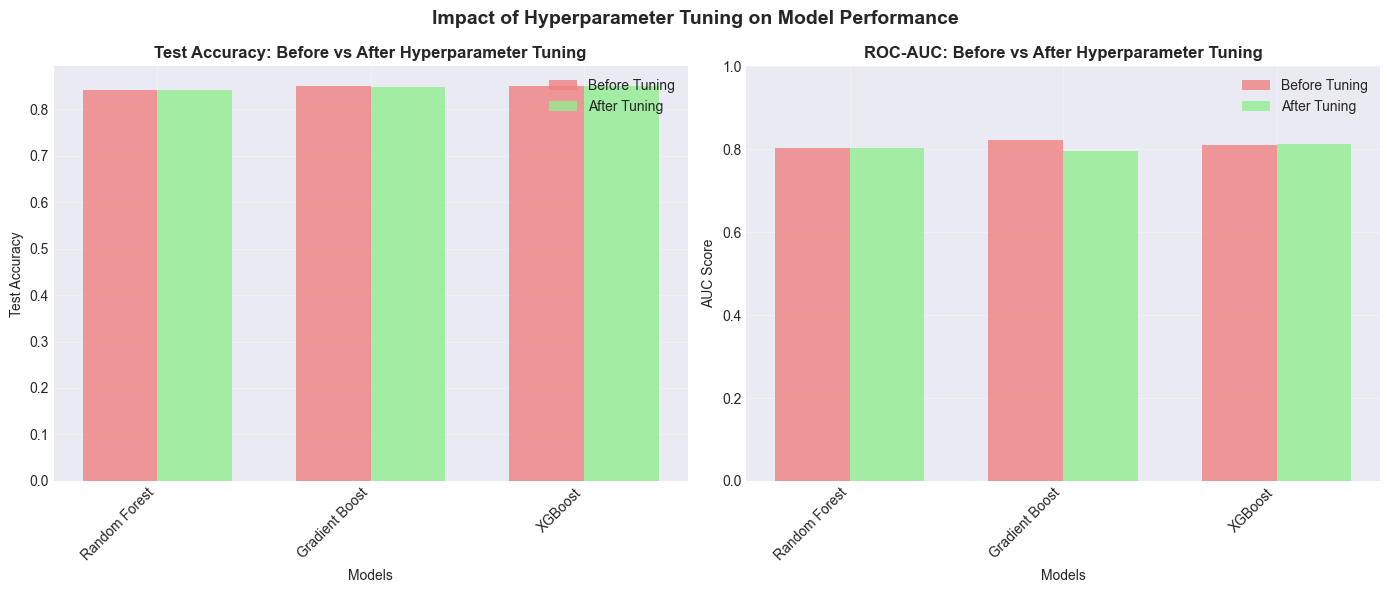

In [53]:
# Visualization of tuning results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Test Accuracy Comparison
ax1 = axes[0]
x = np.arange(len(comparison_df_tuned['Model']))
width = 0.35
ax1.bar(x - width/2, comparison_df_tuned['Before Test Acc'], width, label='Before Tuning', alpha=0.8, color='lightcoral')
ax1.bar(x + width/2, comparison_df_tuned['After Test Acc'], width, label='After Tuning', alpha=0.8, color='lightgreen')
ax1.set_xlabel('Models')
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Test Accuracy: Before vs After Hyperparameter Tuning', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df_tuned['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: AUC Comparison
ax2 = axes[1]
ax2.bar(x - width/2, comparison_df_tuned['Before AUC'], width, label='Before Tuning', alpha=0.8, color='lightcoral')
ax2.bar(x + width/2, comparison_df_tuned['After AUC'], width, label='After Tuning', alpha=0.8, color='lightgreen')
ax2.set_xlabel('Models')
ax2.set_ylabel('AUC Score')
ax2.set_title('ROC-AUC: Before vs After Hyperparameter Tuning', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df_tuned['Model'], rotation=45, ha='right')
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Impact of Hyperparameter Tuning on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
# Final Model Evaluation with Best Tuned Model
print("Final model evaluation - best performing tuned model")

# Find the best model based on test accuracy
best_model_name = max(tuned_results.items(), key=lambda x: x[1]['test_acc'])[0]
best_model_data = tuned_results[best_model_name]
best_model = best_model_data['best_model']

print(f"\nBest Model: {best_model_name}")
print(f"Best Parameters: {best_model_data['best_params']}")
print(f"\nFinal Performance Metrics:")
print(f"Training Accuracy: {best_model_data['train_acc']:.4f}")
print(f"Test Accuracy: {best_model_data['test_acc']:.4f}")
print(f"Cross-validation Score: {best_model_data['cv_score']:.4f}")
print(f"AUC Score: {best_model_data['auc']:.4f}")

Final model evaluation - best performing tuned model

Best Model: XGBoost
Best Parameters: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 200, 'subsample': 1.0}

Final Performance Metrics:
Training Accuracy: 0.8663
Test Accuracy: 0.8492
Cross-validation Score: 0.8593
AUC Score: 0.8139


In [55]:
# Final predictions
y_pred_final = best_model.predict(X_test_scaled)
y_pred_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)


In [56]:
print("cm final: ",cm_final)

cm final:  [[279  17]
 [ 37  25]]


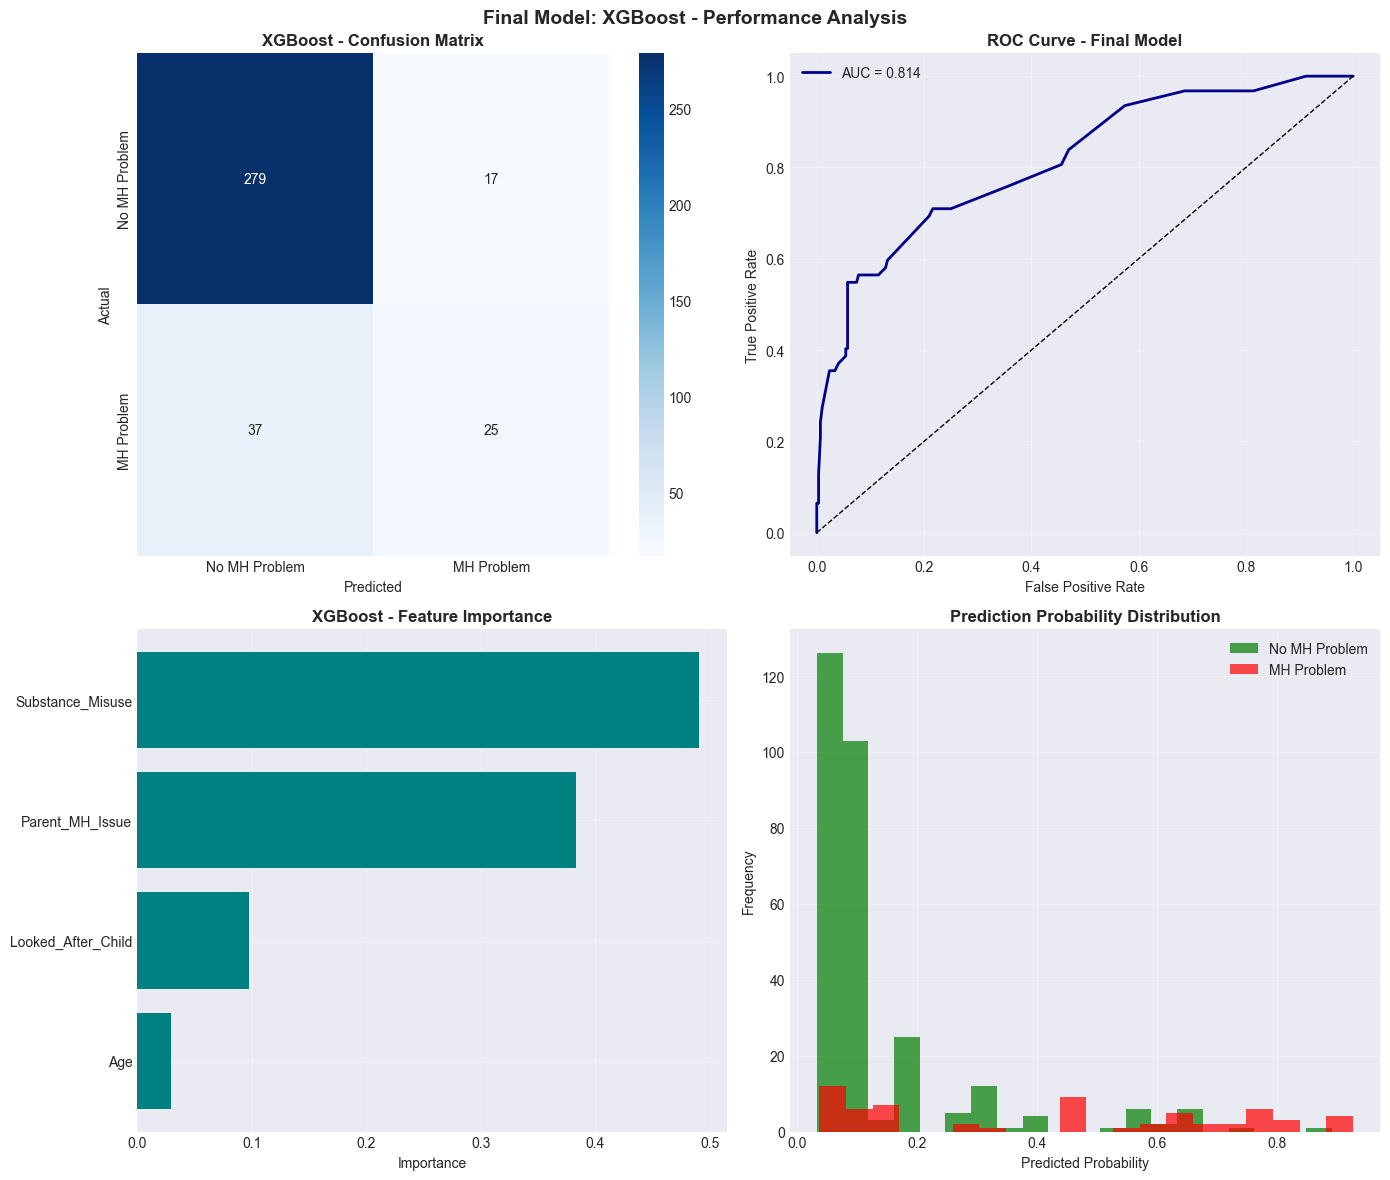

In [57]:
# Visualization of final model results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['No MH Problem', 'MH Problem'],
            yticklabels=['No MH Problem', 'MH Problem'])
ax1.set_title(f'{best_model_name} - Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
ax2.plot(fpr, tpr, linewidth=2, color='darkblue', label=f'AUC = {best_model_data["auc"]:.3f}')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve - Final Model', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
# Feature Importance (if available)
ax3 = axes[1, 0]
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=True)
    
    ax3.barh(importance_df['feature'], importance_df['importance'], color='teal')
    ax3.set_xlabel('Importance')
    ax3.set_title(f'{best_model_name} - Feature Importance', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)

# Prediction Distribution
ax4 = axes[1, 1]
ax4.hist(y_pred_proba_final[y_test==0], bins=20, alpha=0.7, label='No MH Problem', color='green')
ax4.hist(y_pred_proba_final[y_test==1], bins=20, alpha=0.7, label='MH Problem', color='red')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Final Model: {best_model_name} - Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show() 

In [58]:
# Print feature importance for the best model
if hasattr(best_model, 'feature_importances_'):
    print(f"\n{best_model_name} - Feature Importance Rankings:")
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    for idx, row in importance_df.iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")


XGBoost - Feature Importance Rankings:
  Substance_Misuse: 0.4905
  Parent_MH_Issue: 0.3826
  Looked_After_Child: 0.0975
  Age: 0.0294
